# Cryptocurrency Data Preparation

This notebook handles the initial data loading and feature engineering steps for cryptocurrency price prediction:

1. Load the cryptocurrency data
2. Apply feature engineering to create useful predictors
3. Split the data into training and testing sets
4. Export the processed data for use in model training

The engineered features include moving averages, volatility measures, and lagged features.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create models directory if it doesn't exist (for later use)
os.makedirs('../UofT-DSI-Cohort5-ML-T1/models', exist_ok=True)
print("Models directory created/confirmed at ../UofT-DSI-Cohort5-ML-T1/models")

Models directory created/confirmed at ../UofT-DSI-Cohort5-ML-T1/models


In [6]:
# Load the original cryptocurrency data
df = pd.read_csv('../UofT-DSI-Cohort5-ML-T1/data/crypto-markets.csv', parse_dates=['date'])
df = df.sort_values('date')

# --- 1. Remove rows with no meaningful trading data ---
# Drop rows where all prices and volume are zero
df = df[~((df['open'] == 0) & (df['close'] == 0) &
          (df['high'] == 0) & (df['low'] == 0) & (df['volume'] == 0))]

# --- 2. Handle market capitalization issues ---
# Flag rows where market cap is 0 but prices exist (likely missing supply data)
mask_bad_market = (df['market'] == 0) & (
    (df['open'] > 0) | (df['close'] > 0) | (df['high'] > 0) | (df['low'] > 0)
)

# Drop those rows 
df = df[~mask_bad_market]

# --- 3. Handle volume issues ---
# Flag zero-volume records that still have valid prices
df['volume_missing_flag'] = (df['volume'] == 0) & (
    (df['open'] > 0) | (df['close'] > 0) | (df['high'] > 0) | (df['low'] > 0)
)

# --- 4. Filter records with date >= 2013-12-27 to ensure we have volume data

# Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter the DataFrame
df = df[df['date'] >= pd.Timestamp('2013-12-27')]
df.reset_index(drop=True, inplace=True)

# --- 5. Add feature engineering
# For each date, rank coins by market capitalization (highest market cap = rank 1)
df['market_rank'] = df.groupby('date')['market'].rank(method='min', ascending=False)

# --- 6. Reset index and save cleaned dataset ---
df.reset_index(drop=True, inplace=True)
df.to_csv("../UofT-DSI-Cohort5-ML-T1/data/crypto_cleaned.csv", index=False)

print("Cleaning complete. Saved as crypto_cleaned.csv")
print(f"Remaining rows: {len(df)}")
print(f"Rows flagged with missing volume: {df['volume_missing_flag'].sum()}")

Cleaning complete. Saved as crypto_cleaned.csv
Remaining rows: 819318
Rows flagged with missing volume: 18396


In [7]:
# Load the cryptocurrency data
df = pd.read_csv('../UofT-DSI-Cohort5-ML-T1/data/crypto_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print("\nFirst few rows:")
df.head()

Dataset shape: (819318, 15)
Date range: 2013-12-27 00:00:00 to 2018-11-30 00:00:00

First few rows:


,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread,volume_missing_flag,market_rank
0,quark,QRK,Quark,2013-12-27,1282,0.115904,0.122877,0.109992,0.115428,109016.0,28493200.0,0.4219,0.01,False,8.0
22,grandcoin,GDC,GrandCoin,2013-12-27,1577,0.002885,0.002962,0.002293,0.002293,15041.0,618707.0,0.0000,0.00,False,29.0
23,phoenixcoin,PXC,Phoenixcoin,2013-12-27,1391,0.031256,0.031543,0.029005,0.030807,4672.0,235564.0,0.7100,0.00,False,37.0
24,deutsche-emark,DEM,Deutsche eMark,2013-12-27,1036,0.305312,0.383262,0.305312,0.309553,12423.0,858576.0,0.0544,0.08,False,25.0
25,anoncoin,ANC,Anoncoin,2013-12-27,1202,5.210000,5.390000,4.640000,4.810000,16203.0,2975246.0,0.2267,0.75,False,18.0


In [8]:
# Check for missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


slug                   0
symbol                 0
name                   0
date                   0
ranknow                0
open                   0
high                   0
low                    0
close                  0
volume                 0
market                 0
close_ratio            0
spread                 0
volume_missing_flag    0
market_rank            0
dtype: int64

## Feature Engineering

We'll create several engineered features to help with prediction:

1. **Price-based features**: Spread, daily return
2. **Technical indicators**: Moving averages, volatility
3. **Lagged features**: Previous day's values
4. **Target variable**: Next day's close price

In [9]:
# Feature engineering
# Daily Spread: High - Low
df['spread'] = df['high'] - df['low']

# Daily Return: (Close - Open) / Open
df['return'] = (df['close'] - df['open']) / df['open']

# Moving Averages: 3-day, 7-day, 14-day moving averages of Close
df['ma_3'] = df['close'].rolling(window=3).mean()
df['ma_7'] = df['close'].rolling(window=7).mean()
df['ma_14'] = df['close'].rolling(window=14).mean()

# Volatility: Rolling standard deviation of Close (7-day window)
df['volatility_7'] = df['close'].rolling(window=7).std()

# Lag Features: Previous day's Close, Volume
df['close_lag1'] = df['close'].shift(1)
df['volume_lag1'] = df['volume'].shift(1)

# Target: next day's close price
df['target'] = df['close'].shift(-1)

# Drop rows with NaN values (from rolling windows and shifts)
df = df.dropna()

# Display the processed data
print(f"Processed data shape: {df.shape}")
df.head()

Processed data shape: (819304, 23)


,slug,symbol,name,date,ranknow,open,high,low,close,volume,...,volume_missing_flag,market_rank,return,ma_3,ma_7,ma_14,volatility_7,close_lag1,volume_lag1,target
35,terracoin,TRC,Terracoin,2013-12-27,895,0.503765,0.525110,0.450021,0.477796,31077.0,...,False,20.0,-0.051550,12.462599,31.432145,16.151637,66.848936,23.270000,31112200.0,7.34000
36,unobtanium,UNO,Unobtanium,2013-12-27,224,9.390000,9.540000,6.660000,7.340000,21763.0,...,False,27.0,-0.218317,10.362599,32.427043,16.667678,66.359730,0.477796,31077.0,2.28000
37,bullion,CBX,Bullion,2013-12-27,1256,2.480000,2.590000,2.160000,2.280000,12558.0,...,False,22.0,-0.080645,3.365932,32.740334,16.830372,66.186553,7.340000,21763.0,0.19397
38,orbitcoin,ORB,Orbitcoin,2013-12-27,1335,0.217558,0.231440,0.188828,0.193970,4348.0,...,False,38.0,-0.108422,3.271323,6.816615,16.842026,8.773857,2.280000,12558.0,0.04084
39,casinocoin,CSC,CasinoCoin,2013-12-27,369,0.042400,0.046651,0.039655,0.040840,14576.0,...,False,36.0,-0.036792,0.838270,6.748944,16.822832,8.832199,0.193970,4348.0,46.31000


In [10]:
# Calculate the average 'return' for each coin and order in descending order
avg_return_per_coin = df.groupby('symbol')['close'].count().sort_values(ascending=False)
avg_return_per_coin

symbol
BITS     3186
BTM      2043
RED      1877
UNO      1799
DOGE     1799
         ... 
MICRO       2
TRIO        2
PASS        2
COMP        1
ETHO        1
Name: close, Length: 1716, dtype: int64

In [11]:
# Show the 'close' prices for the BITS symbol
bits_close = df[df['symbol'] == 'BITS'][['date', 'close']]
print(bits_close)

             date     close
7438   2014-04-23  0.008506
7538   2014-04-24  0.005218
7600   2014-04-25  0.003843
7689   2014-04-26  0.002680
7799   2014-04-27  0.000889
...           ...       ...
816739 2018-11-28  0.001736
816412 2018-11-28  0.004421
819070 2018-11-29  0.001690
817607 2018-11-29  0.086036
818350 2018-11-29  0.004321

[3186 rows x 2 columns]


In [12]:
# Calculate and display 10-day percent change for each 10th row in bits_close
bits_close['pct_change_10d'] = bits_close['close'].pct_change(periods=10) * 100
bits_close_10d = bits_close.iloc[::10][['date', 'close', 'pct_change_10d']]
bits_close_10d

,date,close,pct_change_10d
7438,2014-04-23,0.008506,NaN
8397,2014-05-03,0.000938,-88.972490
9344,2014-05-13,0.000324,-65.458422
10466,2014-05-23,0.000718,121.604938
11513,2014-06-02,0.000801,11.559889
...,...,...,...
791951,2018-11-14,0.006384,-94.925036
800158,2018-11-18,0.002959,-53.649749
804908,2018-11-21,0.086717,2830.618452
809601,2018-11-24,0.073081,-15.724714


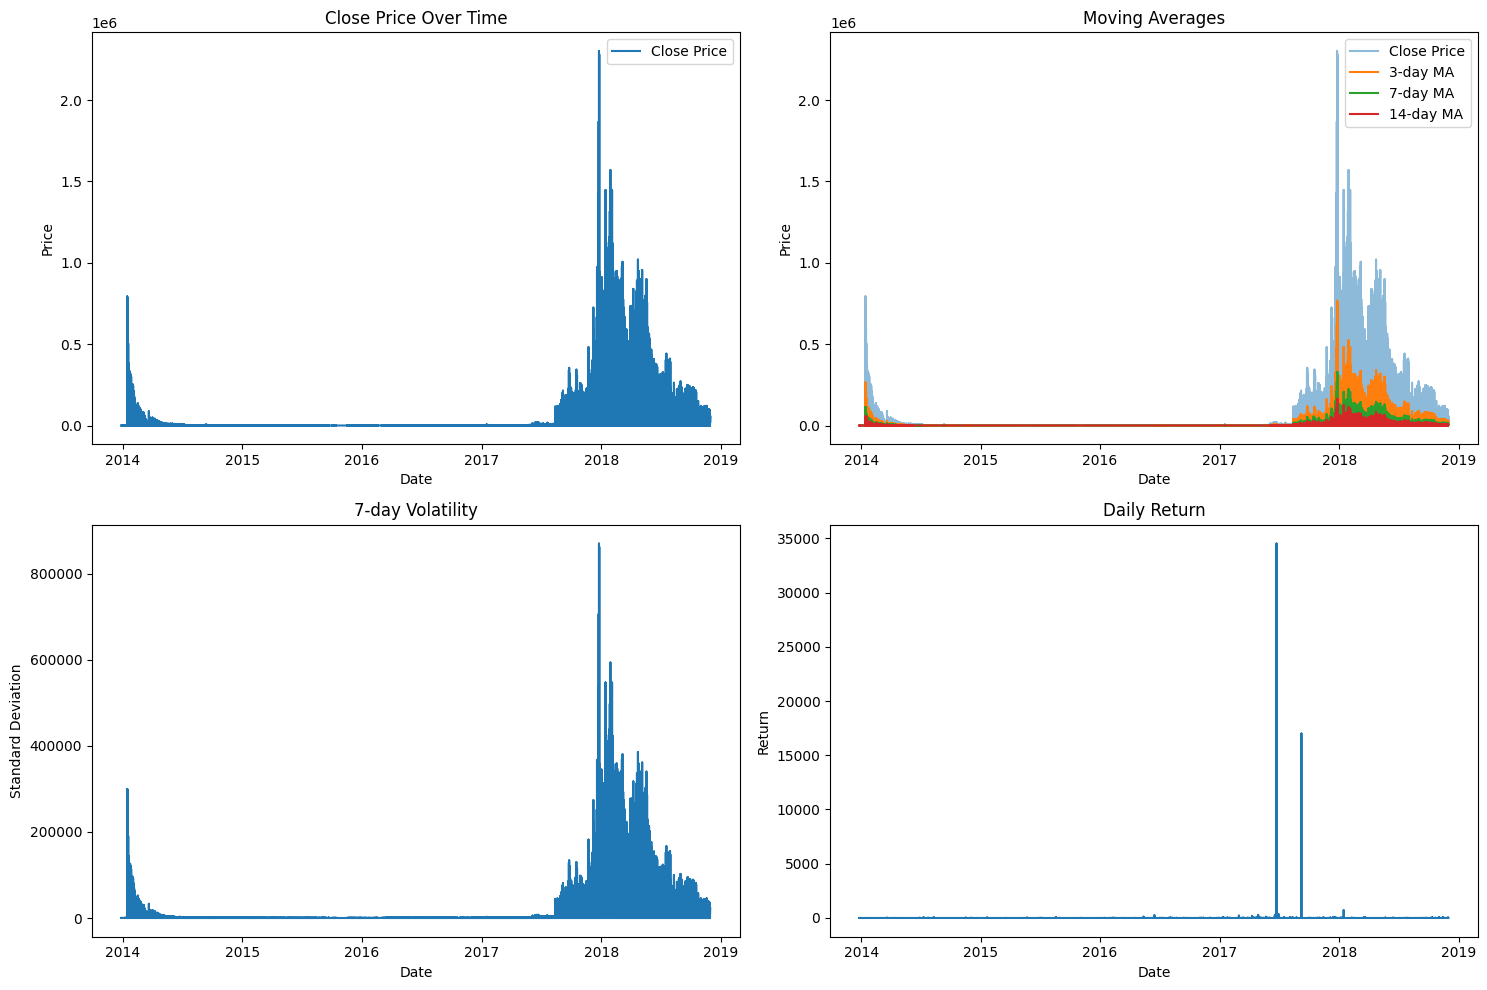

In [13]:
# Visualize the features
plt.figure(figsize=(15, 10))

# Plot 1: Original price
plt.subplot(2, 2, 1)
plt.plot(df['date'], df['close'], label='Close Price')
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Plot 2: Moving averages
plt.subplot(2, 2, 2)
plt.plot(df['date'], df['close'], label='Close Price', alpha=0.5)
plt.plot(df['date'], df['ma_3'], label='3-day MA')
plt.plot(df['date'], df['ma_7'], label='7-day MA')
plt.plot(df['date'], df['ma_14'], label='14-day MA')
plt.title('Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Plot 3: Volatility
plt.subplot(2, 2, 3)
plt.plot(df['date'], df['volatility_7'])
plt.title('7-day Volatility')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')

# Plot 4: Daily Return
plt.subplot(2, 2, 4)
plt.plot(df['date'], df['return'])
plt.title('Daily Return')
plt.xlabel('Date')
plt.ylabel('Return')

plt.tight_layout()
plt.show()

## Data Splitting

We'll use a time-based split for our training and testing sets, which is appropriate for time series data.

In [14]:
# Define the features to be used in modeling
features = ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 
            'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']

# Extract features and target
X = df[features]
y = df['target']

# Create time-based split (80% train, 20% test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Also save the dates for plotting later
dates_train = df['date'].iloc[:split_idx]
dates_test = df['date'].iloc[split_idx:]

print(f"Training set: {len(X_train)} samples ({dates_train.min()} to {dates_train.max()})")
print(f"Testing set: {len(X_test)} samples ({dates_test.min()} to {dates_test.max()})")

Training set: 655443 samples (2013-12-27 00:00:00 to 2018-08-15 00:00:00)
Testing set: 163861 samples (2018-08-15 00:00:00 to 2018-11-30 00:00:00)


In [15]:
# Function to evaluate regression models (will be reused in other notebooks)
def evaluate_regression_model(y_true, y_pred):
    """
    Calculate common regression metrics for model evaluation.
    
    Parameters:
        y_true: True target values
        y_pred: Predicted target values
        
    Returns:
        Dictionary of evaluation metrics
    """
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.metrics import explained_variance_score, median_absolute_error
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    
    # Calculate MAPE with handling for zeros
    epsilon = 1e-10
    y_true_safe = np.maximum(np.abs(y_true), epsilon)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    # Calculate directional accuracy (how often the direction of change is correct)
    actual_direction = np.sign(y_true[1:] - y_true[:-1])
    pred_direction = np.sign(y_pred[1:] - y_pred[:-1])
    directional_accuracy = np.mean(actual_direction == pred_direction) * 100
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': explained_var,
        'Median AE': median_ae,
        'Directional Accuracy (%)': directional_accuracy
    }

In [17]:
# Save the processed data and splits for use in other notebooks
import pickle

# Save the full processed dataframe
df.to_pickle('../UofT-DSI-Cohort5-ML-T1/models/processed_data.pkl')

# Save the feature list
with open('../UofT-DSI-Cohort5-ML-T1/models/features.pkl', 'wb') as f:
    pickle.dump(features, f)

# Save the train-test split data
split_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'dates_train': dates_train,
    'dates_test': dates_test
}

with open('../UofT-DSI-Cohort5-ML-T1/models/train_test_split.pkl', 'wb') as f:
    pickle.dump(split_data, f)

print("Data preparation completed and saved to ../UofT-DSI-Cohort5-ML-T1/models/ directory")
print("Files saved:")
print("- processed_data.pkl: Full processed dataframe")
print("- features.pkl: List of feature names")
print("- train_test_split.pkl: Train-test split data")

Data preparation completed and saved to ../UofT-DSI-Cohort5-ML-T1/models/ directory
Files saved:
- processed_data.pkl: Full processed dataframe
- features.pkl: List of feature names
- train_test_split.pkl: Train-test split data
